### General Imports:


In [1]:
import os
import gymnasium as gym
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
from netsim.gym_basic.envs import MASKING_RMSA_ENV
from netsim.netSimPy import *
import numpy as np
import logging
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

logging.getLogger("tensorflow").setLevel(logging.FATAL)

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# FILES AND DIRECTORIES:
__file__ = "DT_RMSA.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
log_dir = f"./tmp/{file_name}/"
# SIMULATION PARAMS:
EPISODE_LENGTH = 1000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 30000  # 300 Erlangs

networkPaths = "/Users/jbcedeno/Documents/projcts/multiband-gymnasium/networks/nsfnet"
network = Network(
    networkFileName=networkPaths + "/network.json",
    pathsFileName=networkPaths + "/routes.json",
    bitrateFilename=networkPaths + "/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
sim_args = dict(eventsGenerator=generator, network=network)
simulator = NetworkSimulator(**sim_args)
# Building the environment:
env_args = dict(
    simulator=simulator,
    episode_length=EPISODE_LENGTH,
    j=N_BLOCKS,
    n_paths=N_PATHS,
)

env: MASKING_RMSA_ENV = Monitor(gym.make("MASKING_RMSA_ENV-v0", **env_args), log_dir)
eval_env: MASKING_RMSA_ENV = Monitor(
    gym.make("MASKING_RMSA_ENV-v0", **env_args), log_dir + "eval_env"
)

best_model_dir = f"./tmp/ACTION_RMSA_ENV/best_smooth_model"
expert = MaskablePPO.load(best_model_dir)

In [4]:
from sklearn import tree
from netsim.explainable.common.dagger import Dagger
from netsim.explainable.common.beta import linear_beta
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import make_pipeline


n_rounds = 8
beta_func = linear_beta(1, 0, n_rounds)

# model = make_pipeline(
#     RobustScaler(), tree.DecisionTreeClassifier(class_weight="balanced")
# )

student = tree.DecisionTreeClassifier(class_weight="balanced")

dagger_trainer = Dagger(expert, student, env, beta_func)
model = dagger_trainer.train(n_rounds=3, timesteps_by_round=150000, n_evaluations=10000)
# Acceder al clasificador:

# student: LogisticRegression = model.named_steps["decisiontreeclassifier"]

#
#

Starting round 1
Sampling new trajectories for round: {1} 


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


0.8408 [[1474   38    0    0    0  155  256    0    8    4]
 [  34 2921    0    0    0    7  228    0    0    1]
 [   0    1    3    0    0    0    5    0    0    0]
 [   0    0    0   45    1    0    0    1    0    0]
 [   0    0    0    1   17    0    0    0    0    0]
 [ 156   10    0    0    0 1097  103    0    0    0]
 [ 228  230    0    0    0  105 2658    0    0    3]
 [   0    0    0    0    0    0    0   96    0    0]
 [   1    0    0    0    0    0    0    0   51    0]
 [   4    6    0    0    0    2    1    0    3   46]]
Starting round 2
Sampling new trajectories for round: 2 
Fitting student for round: 2 
0.8227 [[1576   17    0    0    0  142  208    0    1    0]
 [ 291 2594    0    0    0   14  239    0    0    7]
 [   0    0    0    0    0    0    1    0    0    0]
 [   0    0    0   48    0    0    0    0    0    0]
 [   0    0    0    6    4    0    0    0    0    0]
 [ 140    8    0    5    0 1154  108    0    0    1]
 [ 203  199    1    0    0  103 2730    0    0    

### Saving the agent


In [5]:
import pickle as pkl

pickle_out = open("student_DT.pkl", "wb")
pkl.dump(student, pickle_out)
pickle_out.close()
# pickle_out = open("student_DT.pkl","rb")
# student = pkl.load(pickle_out)
# pickle_out.close()

### Global accuracy


In [6]:
from netsim.explainable.common.metrics import get_metrics
from netsim.explainable.common.rollout import generate_trajectories
from netsim.explainable.common.masking import predict_with_valid_classes, compute_mask

traj = generate_trajectories(200000, expert, env)
x_test = [t["obs"] for t in traj]
y_test = [int(t["action"]) for t in traj]

masking = compute_mask(env)
y_pred = predict_with_valid_classes(student, x_test, masking)
score = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=[i for i in range(15)])
print(f"Accuracy-score: {score}")
print(f'F1-score: {f1_score(y_test, y_pred, average="weighted")}')
print(conf_matrix)

Accuracy-score: 0.815145
F1-score: 0.8156549540923457
[[30668   447     0     7     0     0     0  2645     0  4073     0    20
     27     0     0]
 [ 6693 52167     0     3     0     0     0   190     0  4675     1     1
     65     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [   11     4     0    69     0     0     0    14     0    37     0     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [    2     0     0     0     0   937     4     0     0     0     0     0
      0     0     0]
 [    0     0     0     0     0   224    93     0     0     0     1     0
      0     0     0]
 [ 2829   188     0     3     0    98     0 23118     0  1852     0     4
      2     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [ 4081  4605     0    21     0    14     0  2015     0 53799     1     0
      6     0    

In [7]:
get_metrics(conf_matrix)

Clase 1:
  Precision: 0.6866
  F1-score: 0.7430
  Sensibilidad (Recall): 0.8095
  Especificidad: 4.2482

Clase 2:
  Precision: 0.9073
  F1-score: 0.8602
  Sensibilidad (Recall): 0.8177
  Especificidad: 4.4863

Clase 3:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 4:
  Precision: 0.6699
  F1-score: 0.5798
  Sensibilidad (Recall): 0.5111
  Especificidad: 1.0455

Clase 5:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 6:
  Precision: 0.4825
  F1-score: 0.6496
  Sensibilidad (Recall): 0.9936
  Especificidad: 156.1667

Clase 7:
  Precision: 0.9490
  F1-score: 0.4471
  Sensibilidad (Recall): 0.2925
  Especificidad: 0.4133

Clase 8:
  Precision: 0.8259
  F1-score: 0.8244
  Sensibilidad (Recall): 0.8229
  Especificidad: 4.6459

Clase 9:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 10:
  Precision: 0.8347
  F1-score: 0.8341
  Sensibilidad (Recall): 0.8336
  Especi

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:6: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(matrix) / np.sum(matrix, axis=0)
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:7: RuntimeWarning: invalid value encountered in divide
  recall = np.diag(matrix) / np.sum(matrix, axis=1)
/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/netsim/explainable/common/metrics.py:8: RuntimeWarning: invalid value encountered in divide
  specificity = np.diag(matrix) / (np.sum(matrix, axis=1) - np.diag(matrix))


### Inter-path accuracy


In [8]:
n_conf_matrix = np.zeros(shape=(3, 3))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n_conf_matrix[ir // 5, ic // 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n_conf_matrix)
print(s[0])
print(n_conf_matrix)

0.87673
[[9.0069e+04 1.1634e+04 1.1400e+02]
 [1.1729e+04 8.2154e+04 1.4000e+01]
 [4.6800e+02 6.9500e+02 3.1230e+03]]


In [9]:
# Matriz de confusión proporcionada
n_conf_matrix = np.array(n_conf_matrix)

get_metrics(n_conf_matrix)

Clase 1:
  Precision: 0.8807
  F1-score: 0.8827
  Sensibilidad (Recall): 0.8846
  Especificidad: 7.6668

Clase 2:
  Precision: 0.8695
  F1-score: 0.8722
  Sensibilidad (Recall): 0.8749
  Especificidad: 6.9960

Clase 3:
  Precision: 0.9606
  F1-score: 0.8287
  Sensibilidad (Recall): 0.7287
  Especificidad: 2.6853



### Inter-spectrum accuracy


In [10]:
n2_conf_matrix = np.zeros(shape=(5, 5))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n2_conf_matrix[ir % 5, ic % 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n2_conf_matrix)
print(s[0])
print(n2_conf_matrix)

0.81657
[[3.3419e+04 4.7300e+02 2.6720e+03 7.0000e+00 4.0730e+03]
 [7.7180e+03 5.2577e+04 2.6000e+02 3.0000e+00 4.6750e+03]
 [3.8460e+03 2.8000e+02 2.3450e+04 3.0000e+00 1.8670e+03]
 [1.1000e+01 4.0000e+00 1.4000e+01 6.9000e+01 3.7000e+01]
 [4.0960e+03 4.6050e+03 2.0210e+03 2.1000e+01 5.3799e+04]]


In [11]:
# Matriz de confusión proporcionada
get_metrics(np.array(n2_conf_matrix))

Clase 1:
  Precision: 0.6808
  F1-score: 0.7448
  Sensibilidad (Recall): 0.8222
  Especificidad: 4.6255

Clase 2:
  Precision: 0.9075
  F1-score: 0.8537
  Sensibilidad (Recall): 0.8060
  Especificidad: 4.1543

Clase 3:
  Precision: 0.8252
  F1-score: 0.8105
  Sensibilidad (Recall): 0.7964
  Especificidad: 3.9109

Clase 4:
  Precision: 0.6699
  F1-score: 0.5798
  Sensibilidad (Recall): 0.5111
  Especificidad: 1.0455

Clase 5:
  Precision: 0.8347
  F1-score: 0.8341
  Sensibilidad (Recall): 0.8336
  Especificidad: 5.0078



In [12]:
def evaluate_bp_student(student, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.reset(options={"lambda": mLambda})
    observation = env.reset()[0]
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        # act = predict([observation], student, env)[0]
        act = predict_with_valid_classes(student, [observation], masking)[0]
        # act = student.predict([observation])[0]
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps


def evaluate_expert(expert, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.reset(options={"lambda": mLambda})
    observation = env.reset()
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        act, state = expert.predict(
            observation,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps

In [13]:
loads = [10000, 12500, 15000, 17500, 20000, 22500, 25000]
N_EVALUATIONS = 200000
lr_bp = []

for l in loads:
    bp = round(evaluate_bp_student(student, N_EVALUATIONS, l), 7)
    print(bp)
    lr_bp.append(bp)
print(lr_bp)

6.5e-05
0.00013
0.00033
0.00097
0.00198
0.004645
0.007945
[6.5e-05, 0.00013, 0.00033, 0.00097, 0.00198, 0.004645, 0.007945]


### features importance


[2.50487812e-04 1.58375353e-03 2.80530744e-03 2.67331168e-02
 1.44367216e-03 7.01045834e-04 1.60210081e-05 6.31462312e-04
 8.51196670e-05 7.42100895e-05 6.82810456e-04 5.42188840e-04
 2.31648287e-04 1.08868707e-04 4.30198597e-04 3.03814090e-04
 1.91115819e-04 4.14357420e-04 5.99317911e-04 1.69380449e-03
 6.39864543e-04 6.07641743e-04 9.58156902e-04 1.58789383e-04
 3.08961429e-04 1.09968862e-04 1.65981378e-04 1.12595578e-03
 1.57416719e-02 6.13808788e-03 9.83804366e-02 2.20731183e-03
 4.49296679e-03 1.72461691e-03 8.51801787e-03 1.97777706e-03
 7.00356564e-03 2.62517201e-03 1.46378744e-02 1.23038572e-01
 1.24905967e-02 4.75523757e-03 3.62020705e-03 1.08520677e-01
 2.05195025e-03 1.13420854e-02 1.98661749e-03 5.21353506e-03
 1.55625584e-03 7.78866500e-03 1.60164658e-03 1.47020728e-03
 4.65499601e-02 6.64157942e-03 6.86801471e-03 2.15192089e-03
 7.89843166e-03 1.02936212e-01 1.02156838e-01 2.36999483e-03
 6.27273000e-03 2.01780677e-03 8.61689688e-03 2.05714780e-03
 6.32036385e-02 4.381777

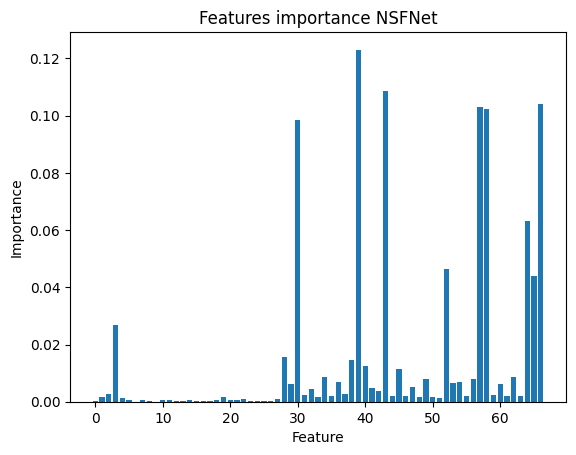

In [ ]:
import pandas as pd

base_output_dir_features = f"./plots/{__file__}/features_importance_heuristic/"

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)

importances_sk = student.feature_importances_
importance = pd.DataFrame(importances_sk)
importance.to_csv(f"{output_dir}features_importance_heuristic.csv")
print(importances_sk)
plt.figure()
plt.bar([x for x in range(len(importances_sk))], importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + "NSFNet.png")
plt.show()